# 
Feature engineering
**Titanic Dataset**<br>
I am *Eyoba*. I am learning how to encode _object_ datatypes in to _numbers_ that machine learning understand.

## Library imports and load csv
* Import Pandas, NumPy, and Matplotlib libraries.
* Read the Titanic CSV file.
* Display the first 5 rows of the dataframe.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df_titanic= pd.read_csv('titanic.csv')
df_titanic.head(5)



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
a_df = pd.read_csv('titanic_ages.csv')
a_df.head(5)

,Name,Age
0,"Moran, Mr. James",22
1,"Williams, Mr. Charles Eugene",23
2,"Masselmani, Mrs. Fatima",22
3,"Emir, Mr. Farred Chehab",29
4,"O'Dwyer, Miss. Ellen ""Nellie""",22


# Name -> Age lookup from the clean dataframe

In [5]:
age_lookup=a_df.set_index('Name')['Age']

# Fill only the missing ages in df, matched by name

In [6]:
df_titanic['Age']=df_titanic['Age'].fillna(df_titanic['Name'].map(age_lookup))

## Dataset Information
Check the total number of rows, column names, data types, and identify missing (null) values.


In [7]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   int64  
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1308 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 122.8+ KB


In [8]:
df_titanic[df_titanic['Age'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
454,455,0,3,"Peduzzi, Mr. Joseph",male,NaN,0,0,A/5 2817,8.05,NaN,S


In [9]:
mask=df_titanic['Name'].str.contains('Peduzzi, Mr. Joseph', na=False)
df_titanic.loc[mask, 'Age']=24

In [10]:
df_titanic[df_titanic['Age'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [11]:
mask=df_titanic['Name'].str.contains('Peduzzi, Mr. Joseph', na=False)
df_titanic.loc[mask, 'Age']=24

In [12]:
df_titanic[df_titanic['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


## Feature Preparation
* **Drop `Cabin`** removed because it has high number of missing values.
* **Drop `Survived`** removed the target variable. 


In [13]:
mask1=df_titanic['Name'].str.contains('Icard, Miss. Amelie', na=False)
df_titanic.loc[mask1, 'Embarked']='S'

In [14]:
df_titanic[df_titanic['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [15]:
mask2 = df_titanic['Name'].str.contains('Stone, Mrs. George Nelson (Martha Evelyn)', na=False, regex=False)
df_titanic.loc[mask2,'Embarked'] = 'S'

In [16]:
x=df_titanic.drop(['Cabin','Survived'], axis=1)

### Isolate target variable to be predicted which is survived

In [17]:
y=df_titanic['Survived']

### Display the first 5 rows of the `x` dataframe.

In [18]:
x.head(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


### Display the first 5 rows of the `y` series.

In [19]:
y.head(5)

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

## Handling missing data
* **Age** filled missing values with the column median.
* **Fare** filled the missing value with the column median.
* **Embarked** filled missing ports with the most common value (mode).


In [20]:
x['Age']=x['Age'].fillna(x['Age'].median())

#Fill the missing single Fare with the median fare
x['Fare']=x['Fare'].fillna(x['Fare'].median())

#Fill the missing Embarked with the most common port (mode)
x['Embraked']=x['Embarked'].fillna(x['Embarked'].mode())




## Distribution of target variable
* Count and plot the frequency of survival outcomes using a bar chart.
* Check for imbalance between survivors (1) and non-survivors (0).


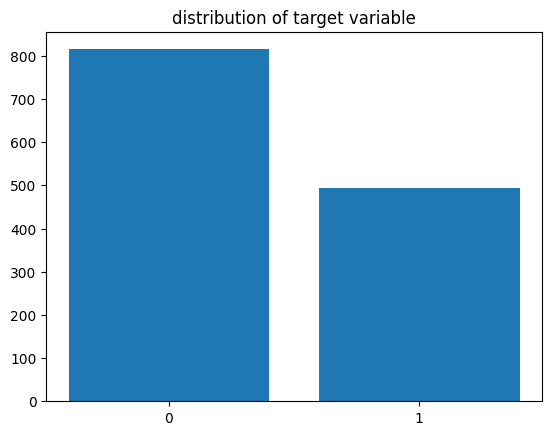

In [21]:
x_plot=y.value_counts()
plt.bar(x_plot.index, x_plot)
plt.gca().set_xticks([0,1])
plt.title('distribution of target variable')
plt.show()


## Feature Encoding 
* Import `LabelEncoder` from `scikit-learn` to prepare transform text categories into numerical values for model compatibility.


In [22]:
from sklearn.preprocessing import LabelEncoder

## Using label encoding
* Created a new `train` DataFrame and initialized to `LabelEncoder`.
* Looped through all columns in the `x` DataFrame and converted any `object` (text) data type column into numeric labels, while keeping numerical columns unchanged.


In [23]:
train=pd.DataFrame()
label=LabelEncoder()
for c in x.columns:
    if(x[c].dtype=='object'):
        train[c]=label.fit_transform(x[c])
    else:
        train[c]=x[c]

### Display the first 5 rows of the `train` Dataframe.

In [24]:
train.head(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Embraked
0,1,3,155,1,22.0,1,0,720,7.2500,2,2
1,2,1,286,0,38.0,1,0,816,71.2833,0,0
2,3,3,523,0,26.0,0,0,914,7.9250,2,2
3,4,1,422,0,35.0,1,0,65,53.1000,2,2
4,5,3,22,1,35.0,0,0,649,8.0500,2,2


* Imported`train_test_split` to split data into a training group and a testing group.
* Imported `LogisticRegression` as the model that will learn from the data.
* Imported `accuracy_score` to measure model performance.
* Imported `KFold` and `base` to test the model multiple times to make sure it works well.


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn import base

## Logistic Regression ##
* Created a function called `logistic` that takes features (`x`) and labels (`y`) as parameters.
* Split the data into 80% for training the model and 20% for testing it.
* Trained the model using the training data.
* Made predictions on the test data and printed out the final accuracy score.


In [26]:
def logistic(x,y):
    x_train, x_test, y_train, y_test= train_test_split(x,y, random_state=42, test_size=0.2)
    lr=LogisticRegression()
    lr.fit(x_train,y_train)
    y_pre=lr.predict(x_test)
    print('Accuracy : ', accuracy_score(y_test,y_pre))

* Ran the `logistic` function using our processed features (`train`) and target labels (`y`).

In [27]:
logistic(train,y)

Accuracy :  0.816793893129771


/home/Student/.local/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Load the csv for the missing ages in the dataset
* Load the csv of the missing age values from the dataset and look at the first 5 rows to see it loading has worked

In [28]:
a_df = pd.read_csv('titanic_ages.csv')
a_df.head(5)

,Name,Age
0,"Moran, Mr. James",22
1,"Williams, Mr. Charles Eugene",23
2,"Masselmani, Mrs. Fatima",22
3,"Emir, Mr. Farred Chehab",29
4,"O'Dwyer, Miss. Ellen ""Nellie""",22


## Load the csv for the missing emarked column values in the dataset
* Load the csv of the missing embarked values from the dataset and look at the first rows to see it loading has worked.

In [29]:
e_df = pd.read_csv('titanic_embarked.csv')
e_df.head(2)


,Name,Embarked
0,"Icard, Miss. Amelie",S
1,"Stone, Mrs. George Nelson (Martha Evelyn)",S


## On hot encoding 


* **Import OneHotEncoder:** It imports the `OneHotEncoder` class from the `preprocessing` module of **Scikit-Learn** (`sklearn`), which is the standard machine learning library for Python.


In [30]:
from sklearn.preprocessing import OneHotEncoder

In [31]:
train=pd.get_dummies(x).astype(np.int8)
print('train data set has got {} rows and {} columns'.format(train.shape[0],train.shape[1]))

train data set has got 1309 rows and 2250 columns


In [32]:
df_list = []
label = OneHotEncoder(sparse_output=False)

for c in x.columns:
    if x[c].dtype == 'object':
        encoded_array = label.fit_transform(x[[c]])
        
        col_names = label.get_feature_names_out([c])
        temp_df = pd.DataFrame(encoded_array, columns=col_names, index=x.index)
        df_list.append(temp_df)
    else:
        df_list.append(x[[c]])

train2 = pd.concat(df_list, axis=1)
print(f'train2 data set has got {train2.shape[0]} rows and {train2.shape[1]} columns\n')


train2 data set has got 1309 rows and 2250 columns



In [33]:
logistic(train2,y)

Accuracy :  0.8549618320610687


/home/Student/.local/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [34]:
train2.head()

,PassengerId,Pclass,"Name_Abbing, Mr. Anthony","Name_Abbott, Master. Eugene Joseph","Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelseth, Miss. Karen Marie","Name_Abelseth, Mr. Olaus Jorgensen","Name_Abelson, Mr. Samuel","Name_Abelson, Mrs. Samuel (Hannah Wizosky)",...,Ticket_W.E.P. 5734,Ticket_W/C 14208,Ticket_WE/P 5735,Fare,Embarked_C,Embarked_Q,Embarked_S,Embraked_C,Embraked_Q,Embraked_S
0,1,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,7.2500,0.0,0.0,1.0,0.0,0.0,1.0
1,2,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,71.2833,1.0,0.0,0.0,1.0,0.0,0.0
2,3,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,7.9250,0.0,0.0,1.0,0.0,0.0,1.0
3,4,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,53.1000,0.0,0.0,1.0,0.0,0.0,1.0
4,5,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,8.0500,0.0,0.0,1.0,0.0,0.0,1.0
